Evaluation Graphs for ANN

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test

data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [2]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

baseline_hidden_sizes = (128, 64)
detector = build_detector(
    train_paths,
    history=history,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    hidden_sizes=baseline_hidden_sizes,
)

# train_results = [detector.detect(path) for path in train_paths[:3]]
# test_results = [detector.detect(path) for path in test_paths[:3]]

disp = detector.prediction_confusion_matrix(test_paths[1])

In [ ]:
# Save the model weights
torch.save(detector.model.state_dict(), "weights/model_weights.pth")

# Save the scalers (for preprocessing)
with open("weights/scalers.pkl", "wb") as f:
    pickle.dump(detector.scalers, f)

# Save the threshold config
with open("weights/threshold.pkl", "wb") as f:
    pickle.dump(detector.threshold, f)

# Optionally save other metadata
metadata = {
    "history": detector.history,
    "groups": detector.groups,
    "device": str(detector.device),
}
with open("weights/metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

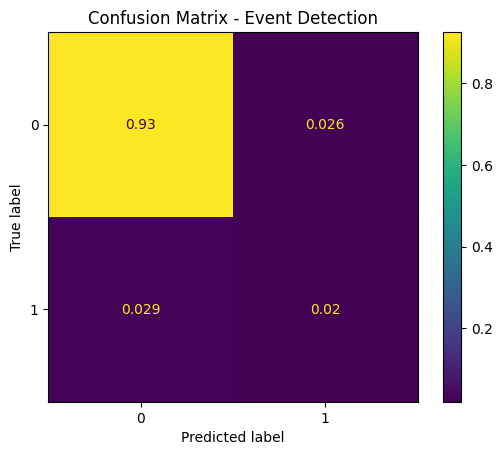

In [3]:
disp.plot()
plt.title('Confusion Matrix - Event Detection')
plt.show()


In [ ]:
# load and recreate the model and detector for future use with the saved weights and scalers

import torch
import pickle
from src.event_detection_pipeline.model import WaterQualityANN
from src.event_detection_pipeline.pipeline import EventDetector

# Load saved components
model_weights = torch.load("weights/model_weights.pth")
with open("weights/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)
with open("weights/threshold.pkl", "rb") as f:
    threshold = pickle.load(f)
with open("weights/metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

# Recreate model and detector
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WaterQualityANN(input_dim=..., output_dim=..., hidden_sizes=(...))
model.load_state_dict(model_weights)
model.to(device)

# Recreate detector
detector = EventDetector(
    model=model,
    scalers=scalers,
    threshold=threshold,
    true_positive_rate=...,  # You'll need to save/retrieve this too
    false_positive_rate=...,
    device=device,
    history=metadata["history"],
    groups=metadata["groups"],
)

In [ ]:
result = detector.detect(test_path)

# Get summary metrics
summary = get_evaluation_summary(result)
print(summary)

# Plot ROC curve for event detection
fpr, tpr, auc, fig, ax = plot_roc_curve_event_detection(result)
plt.show()

# Plot ROC curve for chlorine (if you know chlorine indices)
fpr_cl, tpr_cl, auc_cl, fig_cl, ax_cl = plot_roc_curve_chlorine_prediction(
    result, 
    chlorine_indices=[0, 1, 2]  # adjust to your chlorine sensor indices
)
plt.show()

# Precision-Recall curve
precision, recall, f1_scores, fig, ax = plot_precision_recall_curve(result)
plt.show()